# Zero-shot Classification with CLIP (Class-based)
1. Config Resolve
2. Dataset + EDA
3. Data Loader
4. Pipelines (Input, Preprocess, Backbone, Head, Output)
5. Evaluate (Accuracy, Precision, Recall, F1 and Macro variants)
6. Analysis (model size, inference time, confidence analysis)

In [1]:
import json
import time
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn.functional as F
import yaml
from PIL import Image
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
@dataclass
class AppConfig:
    project_root: Path
    config_path: Path
    data_path: Path
    train_path: Path
    val_path: Path
    test_path: Path
    images_dir: Path
    labels: List[str]
    label_prompts: List[str]
    clip_model: str
    batch_size: int
    max_samples: Optional[int]
    cls_report: bool


class ConfigResolver:
    def __init__(self, config_path: Optional[str] = None):
        self.config_path_input = config_path

    def _find_config_path(self) -> Path:
        if self.config_path_input:
            p = Path(self.config_path_input).expanduser().resolve()
            if not p.exists():
                raise FileNotFoundError(f"Config file not found: {p}")
            return p

        candidates = [
            Path.cwd() / "config.yaml",
            Path.cwd() / "Multimodal" / "config.yaml",
        ]
        for c in candidates:
            if c.exists():
                return c.resolve()

        raise FileNotFoundError("Could not locate config.yaml (checked cwd and cwd/Multimodal).")

    @staticmethod
    def _read_yaml(path: Path) -> Dict:
        with path.open("r", encoding="utf-8") as f:
            data = yaml.safe_load(f)
        if not isinstance(data, dict):
            raise ValueError("Config must be a YAML mapping.")
        return data

    def resolve(self) -> AppConfig:
        config_path = self._find_config_path()
        project_root = config_path.parent
        raw = self._read_yaml(config_path)

        paths_cfg = raw.get("paths", {})
        model_cfg = raw.get("model", {})
        runtime_cfg = raw.get("runtime", {})

        labels = raw.get("labels", [])
        if not labels:
            raise ValueError("Config labels is empty.")

        prompt_template = "a news article about {label_lower}"
        label_prompts = [
            prompt_template.format(label_lower=label.lower()) for label in labels
        ]

        def make_path(key: str, default: str = "") -> Path:
            value = paths_cfg.get(key, default)
            return (project_root / value).resolve()

        max_samples = runtime_cfg.get("max_samples", None)
        max_samples = int(max_samples) if max_samples is not None else None

        return AppConfig(
            project_root=project_root,
            config_path=config_path,
            data_path=make_path("data_path"),
            train_path=make_path("train_path"),
            val_path=make_path("val_path"),
            test_path=make_path("test_path"),
            images_dir=make_path("images_dir"),
            labels=labels,
            label_prompts=label_prompts,
            clip_model=model_cfg.get("clip_model", "openai/clip-vit-base-patch32"),
            batch_size=int(runtime_cfg.get("batch_size", 32)),
            max_samples=max_samples,
            cls_report=bool(runtime_cfg.get("cls_report", True)),
        )

In [3]:
class N24NewsDataset(Dataset):
    def __init__(self, items: List[Dict], labels: List[str]):
        self.items = items
        self.labels = labels

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> Dict:
        return self.items[idx]

    @staticmethod
    def resolve_image_path(images_dir: Path, image_id: str) -> Optional[Path]:
        if not image_id:
            return None

        image_id = str(image_id)
        direct = images_dir / image_id
        if direct.exists():
            return direct

        with_jpg = images_dir / f"{image_id}.jpg"
        if with_jpg.exists():
            return with_jpg

        for ext in (".jpeg", ".png", ".webp"):
            candidate = images_dir / f"{image_id}{ext}"
            if candidate.exists():
                return candidate

        matches = list(images_dir.glob(f"{image_id}.*"))
        return matches[0] if matches else None

    @staticmethod
    def build_text(row: Dict) -> str:
        fields = [row.get("headline", ""), row.get("abstract", ""), row.get("caption", "")]
        text = " ".join([p.strip() for p in fields if isinstance(p, str) and p.strip()])
        return text if text else " "

    @classmethod
    def from_json(
        cls,
        json_path: Path,
        images_dir: Path,
        labels: List[str],
        max_samples: Optional[int] = None,
    ) -> "N24NewsDataset":
        if not json_path.exists():
            raise FileNotFoundError(f"JSON file not found: {json_path}")
        if not images_dir.exists():
            raise FileNotFoundError(f"Images directory not found: {images_dir}")

        with json_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        if not isinstance(data, list):
            raise ValueError("Expected dataset JSON to be a list.")

        items: List[Dict] = []
        missing_images = 0
        unknown_labels = 0

        for idx, row in enumerate(data):
            if not isinstance(row, dict):
                continue

            label = row.get("section")
            if label not in labels:
                unknown_labels += 1
                continue

            image_path = cls.resolve_image_path(images_dir, row.get("image_id"))
            if image_path is None:
                missing_images += 1
                continue

            items.append(
                {
                    "id": row.get("id", idx),
                    "image": image_path,
                    "label": label,
                    "text": cls.build_text(row),
                }
            )

        if max_samples is not None:
            items = items[:max_samples]

        print(f"Valid samples: {len(items)}")
        print(f"Skipped missing images: {missing_images}")
        print(f"Skipped unknown labels: {unknown_labels}")

        if not items:
            raise RuntimeError("No valid samples found.")

        return cls(items=items, labels=labels)

    def eda_summary(self, top_k: int = 10) -> Dict:
        label_counts = Counter([x["label"] for x in self.items])
        text_lengths = [len(x["text"].split()) for x in self.items]

        summary = {
            "num_samples": len(self.items),
            "num_classes": len(label_counts),
            "class_distribution": dict(label_counts),
            "text_len_mean": float(np.mean(text_lengths)) if text_lengths else 0.0,
            "text_len_median": float(np.median(text_lengths)) if text_lengths else 0.0,
            "text_len_p90": float(np.percentile(text_lengths, 90)) if text_lengths else 0.0,
        }

        print("=== EDA Summary ===")
        print(f"Samples: {summary['num_samples']}")
        print(f"Classes: {summary['num_classes']}")
        print(f"Text length (mean/median/p90): {summary['text_len_mean']:.2f} / {summary['text_len_median']:.2f} / {summary['text_len_p90']:.2f}")

        print("\nTop class frequencies:")
        for label, count in label_counts.most_common(top_k):
            print(f"- {label}: {count}")

        return summary

In [4]:
class DataLoaderFactory:
    @staticmethod
    def collate_fn(batch: List[Dict]) -> List[Dict]:
        return batch

    @classmethod
    def build(cls, dataset: Dataset, batch_size: int, shuffle: bool = False, num_workers: int = 0) -> DataLoader:
        return DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            collate_fn=cls.collate_fn,
        )

In [5]:
class ZeroShotCLIPPipeline:
    def __init__(self, cfg: AppConfig, device: str = DEVICE):
        self.cfg = cfg
        self.device = device
        self.model = CLIPModel.from_pretrained(cfg.clip_model).to(self.device)
        self.model.eval()
        self.processor = CLIPProcessor.from_pretrained(cfg.clip_model, use_fast=False)

        self.labels = cfg.labels
        self.label_prompts = cfg.label_prompts
        self.label_text_features = self._encode_label_prompts()

    # 1) Input
    def input_stage(self, batch: List[Dict]) -> Tuple[List[Image.Image], List[str], List[str], List[str]]:
        images: List[Image.Image] = []
        texts: List[str] = []
        labels: List[str] = []
        ids: List[str] = []

        for item in batch:
            ids.append(str(item.get("id", "")))
            labels.append(item["label"])
            texts.append(item.get("text", " ") or " ")

            try:
                image = Image.open(item["image"]).convert("RGB")
            except Exception:
                image = Image.new("RGB", (224, 224), color=(128, 128, 128))
            images.append(image)

        return images, texts, labels, ids

    # 2) Preprocess
    def preprocess_stage(
        self,
        images: Optional[List[Image.Image]] = None,
        texts: Optional[List[str]] = None,
    ) -> Dict[str, torch.Tensor]:
        if images is not None:
            return self.processor(images=images, return_tensors="pt").to(self.device)
        if texts is not None:
            return self.processor(text=texts, padding=True, truncation=True, return_tensors="pt").to(self.device)
        raise ValueError("Provide either images or texts for preprocessing.")

    # 3) Backbone
    def backbone_stage(
        self,
        image_inputs: Optional[Dict[str, torch.Tensor]] = None,
        text_inputs: Optional[Dict[str, torch.Tensor]] = None,
    ) -> torch.Tensor:
        with torch.no_grad():
            if image_inputs is not None:
                feats = self.model.get_image_features(**image_inputs)
            elif text_inputs is not None:
                feats = self.model.get_text_features(**text_inputs)
            else:
                raise ValueError("Provide either image_inputs or text_inputs for backbone.")
        return F.normalize(feats, dim=-1)

    # 4) Head
    def head_stage(self, query_features: torch.Tensor) -> torch.Tensor:
        return query_features @ self.label_text_features.T

    # 5) Output
    def output_stage(self, logits: torch.Tensor) -> Dict:
        probs = torch.softmax(logits, dim=-1)
        conf, pred_idx = probs.max(dim=1)
        pred_labels = [self.labels[i] for i in pred_idx.cpu().tolist()]
        return {
            "logits": logits,
            "probs": probs,
            "pred_idx": pred_idx.cpu().tolist(),
            "pred_labels": pred_labels,
            "confidence": conf.cpu().tolist(),
        }

    def _encode_label_prompts(self) -> torch.Tensor:
        inputs = self.preprocess_stage(texts=self.label_prompts)
        return self.backbone_stage(text_inputs=inputs)

    def _encode_batch_text(self, texts: List[str]) -> torch.Tensor:
        inputs = self.preprocess_stage(texts=texts)
        return self.backbone_stage(text_inputs=inputs)

    def predict_batch(self, batch: List[Dict], multimodal_alpha: float = 0.7) -> Dict:
        images, texts, labels, ids = self.input_stage(batch)

        image_inputs = self.preprocess_stage(images=images)
        image_features = self.backbone_stage(image_inputs=image_inputs)
        image_logits = self.head_stage(image_features)
        image_out = self.output_stage(image_logits)

        text_features = self._encode_batch_text(texts)
        text_logits = self.head_stage(text_features)
        text_out = self.output_stage(text_logits)

        mm_logits = multimodal_alpha * image_logits + (1.0 - multimodal_alpha) * text_logits
        mm_out = self.output_stage(mm_logits)

        return {
            "ids": ids,
            "true_labels": labels,
            "image": image_out,
            "text": text_out,
            "multimodal": mm_out,
        }

    def run_inference(self, loader: DataLoader, multimodal_alpha: float = 0.7, show_progress: bool = True) -> List[Dict]:
        records: List[Dict] = []
        iterator = tqdm(loader, desc="Zero-shot Inference") if show_progress else loader

        for batch in iterator:
            out = self.predict_batch(batch, multimodal_alpha=multimodal_alpha)

            for i in range(len(batch)):
                records.append(
                    {
                        "id": out["ids"][i],
                        "true_label": out["true_labels"][i],
                        "image_pred": out["image"]["pred_labels"][i],
                        "image_confidence": float(out["image"]["confidence"][i]),
                        "text_pred": out["text"]["pred_labels"][i],
                        "text_confidence": float(out["text"]["confidence"][i]),
                        "multimodal_pred": out["multimodal"]["pred_labels"][i],
                        "multimodal_confidence": float(out["multimodal"]["confidence"][i]),
                    }
                )

        return records

In [6]:
class Evaluator:
    def __init__(self, labels: List[str]):
        self.labels = labels

    @staticmethod
    def _macro_accuracy_from_confusion(cm: np.ndarray) -> float:
        per_class_acc = []
        for i in range(cm.shape[0]):
            denom = cm[i].sum()
            acc_i = (cm[i, i] / denom) if denom > 0 else 0.0
            per_class_acc.append(acc_i)
        return float(np.mean(per_class_acc)) if per_class_acc else 0.0

    def evaluate(self, y_true: List[str], y_pred: List[str]) -> Dict:
        if len(y_true) == 0:
            raise ValueError("Empty y_true.")

        y_true_np = np.array(y_true)
        y_pred_np = np.array(y_pred)

        accuracy = float(np.mean(y_true_np == y_pred_np))
        precision = precision_score(y_true, y_pred, labels=self.labels, average="weighted", zero_division=0)
        recall = recall_score(y_true, y_pred, labels=self.labels, average="weighted", zero_division=0)
        f1 = f1_score(y_true, y_pred, labels=self.labels, average="weighted", zero_division=0)

        macro_precision = precision_score(y_true, y_pred, labels=self.labels, average="macro", zero_division=0)
        macro_recall = recall_score(y_true, y_pred, labels=self.labels, average="macro", zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, labels=self.labels, average="macro", zero_division=0)

        cm = confusion_matrix(y_true, y_pred, labels=self.labels)
        macro_accuracy = self._macro_accuracy_from_confusion(cm)

        p_cls, r_cls, f1_cls, support_cls = precision_recall_fscore_support(
            y_true, y_pred, labels=self.labels, average=None, zero_division=0
        )

        per_class = []
        for i, label in enumerate(self.labels):
            per_class.append(
                {
                    "label": label,
                    "precision": float(p_cls[i]),
                    "recall": float(r_cls[i]),
                    "f1": float(f1_cls[i]),
                    "support": int(support_cls[i]),
                }
            )

        return {
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "macro_accuracy": float(macro_accuracy),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "confusion_matrix": cm,
            "per_class": per_class,
        }

    def evaluate_from_records(self, records: List[Dict], pred_key: str) -> Dict:
        y_true = [x["true_label"] for x in records]
        y_pred = [x[pred_key] for x in records]
        return self.evaluate(y_true, y_pred)

    @staticmethod
    def print_metrics(title: str, metrics: Dict) -> None:
        print(f"\n=== {title} ===")
        print(f"Accuracy:         {metrics['accuracy']:.4f}")
        print(f"Precision:        {metrics['precision']:.4f}")
        print(f"Recall:           {metrics['recall']:.4f}")
        print(f"F1-score:         {metrics['f1']:.4f}")
        print(f"Macro Accuracy:   {metrics['macro_accuracy']:.4f}")
        print(f"Macro Precision:  {metrics['macro_precision']:.4f}")
        print(f"Macro Recall:     {metrics['macro_recall']:.4f}")
        print(f"Macro F1-score:   {metrics['macro_f1']:.4f}")

In [7]:
class Analyzer:
    def __init__(self, pipeline: ZeroShotCLIPPipeline):
        self.pipeline = pipeline

    @staticmethod
    def model_params_info(model: torch.nn.Module) -> Dict:
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

        size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
        size_mb = size_bytes / (1024 ** 2)

        return {
            "total_params": int(total_params),
            "trainable_params": int(trainable_params),
            "model_size_mb": float(size_mb),
        }

    def benchmark_inference_time(
        self,
        loader: DataLoader,
        multimodal_alpha: float = 0.7,
        warmup_steps: int = 2,
        timed_steps: int = 10,
    ) -> Dict:
        batches = []
        for i, batch in enumerate(loader):
            batches.append(batch)
            if i >= warmup_steps + timed_steps - 1:
                break

        if len(batches) <= warmup_steps:
            raise RuntimeError("Not enough batches for inference benchmark.")

        for b in batches[:warmup_steps]:
            _ = self.pipeline.predict_batch(b, multimodal_alpha=multimodal_alpha)

        if self.pipeline.device == "cuda":
            torch.cuda.synchronize()

        total_samples = 0
        t0 = time.perf_counter()
        for b in batches[warmup_steps:]:
            _ = self.pipeline.predict_batch(b, multimodal_alpha=multimodal_alpha)
            total_samples += len(b)
        if self.pipeline.device == "cuda":
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

        return {
            "timed_steps": len(batches[warmup_steps:]),
            "total_samples": int(total_samples),
            "total_seconds": float(elapsed),
            "seconds_per_sample": float(elapsed / max(total_samples, 1)),
            "samples_per_second": float(total_samples / max(elapsed, 1e-12)),
        }

    @staticmethod
    def confidence_analysis(
        records: List[Dict],
        pred_key: str,
        conf_key: str,
        bin_edges: Optional[List[float]] = None,
    ) -> List[Dict]:
        if bin_edges is None:
            bin_edges = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

        buckets: List[Dict] = []
        for i in range(len(bin_edges) - 1):
            lo, hi = bin_edges[i], bin_edges[i + 1]
            if i < len(bin_edges) - 2:
                subset = [r for r in records if lo <= r[conf_key] < hi]
            else:
                subset = [r for r in records if lo <= r[conf_key] <= hi]

            if subset:
                correct = [1 if r[pred_key] == r["true_label"] else 0 for r in subset]
                acc = float(np.mean(correct))
                avg_conf = float(np.mean([r[conf_key] for r in subset]))
            else:
                acc = 0.0
                avg_conf = 0.0

            buckets.append(
                {
                    "bin": f"[{lo:.1f}, {hi:.1f}]",
                    "count": len(subset),
                    "accuracy": acc,
                    "avg_confidence": avg_conf,
                }
            )

        return buckets

    @staticmethod
    def print_confidence_table(title: str, table: List[Dict]) -> None:
        print(f"\n=== {title} Confidence Analysis ===")
        print("Bin        | Count | Accuracy | Avg Confidence")
        print("-----------------------------------------------")
        for row in table:
            print(
                f"{row['bin']:<10} | {row['count']:>5} | {row['accuracy']:.4f}   | {row['avg_confidence']:.4f}"
            )

In [ ]:
# 1) Config Resolve
cfg = ConfigResolver().resolve()
print(f"Config path: {cfg.config_path}")
print(f"Data path:   {cfg.data_path}")
print(f"Images dir:  {cfg.images_dir}")
print(f"CLIP model:  {cfg.clip_model}")
print(f"Batch size:  {cfg.batch_size}")

# 2) Dataset + EDA
dataset = N24NewsDataset.from_json(
    json_path=cfg.data_path,
    images_dir=cfg.images_dir,
    labels=cfg.labels,
    max_samples=cfg.max_samples,
)
eda = dataset.eda_summary(top_k=24)

# 3) Data Loader
loader = DataLoaderFactory.build(dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f"Total batches: {len(loader)}")

# 4) Pipeline
pipeline = ZeroShotCLIPPipeline(cfg, device=DEVICE)
evaluator = Evaluator(cfg.labels)
analyzer = Analyzer(pipeline)

Config path: D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\config.yaml
Data path:   D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\data\news\nytimes_dataset.json
Images dir:  D:\Study\BK-OISP\DLA\Assignment\1\Multimodal\data\imgs
CLIP model:  openai/clip-vit-base-patch32
Batch size:  32
Valid samples: 61218
Skipped missing images: 0
Skipped unknown labels: 0
=== EDA Summary ===
Samples: 61218
Classes: 24
Text length (mean/median/p90): 48.75 / 49.00 / 65.00

Top class frequencies:
- Health: 3000
- Science: 3000
- Television: 3000
- Travel: 3000
- Movies: 3000
- Dance: 3000
- Real Estate: 3000
- Sports: 3000
- Theater: 3000
- Opinion: 3000
- Music: 3000
- Books: 3000
- Art & Design: 3000
- Media: 3000
- Food: 3000
- Fashion: 3000
- Technology: 3000
- Style: 2681
- Automobiles: 1825
- Economy: 1761
- Your Money: 1263
- Global Business: 1182
- Education: 825
- Well: 681
Total batches: 1914


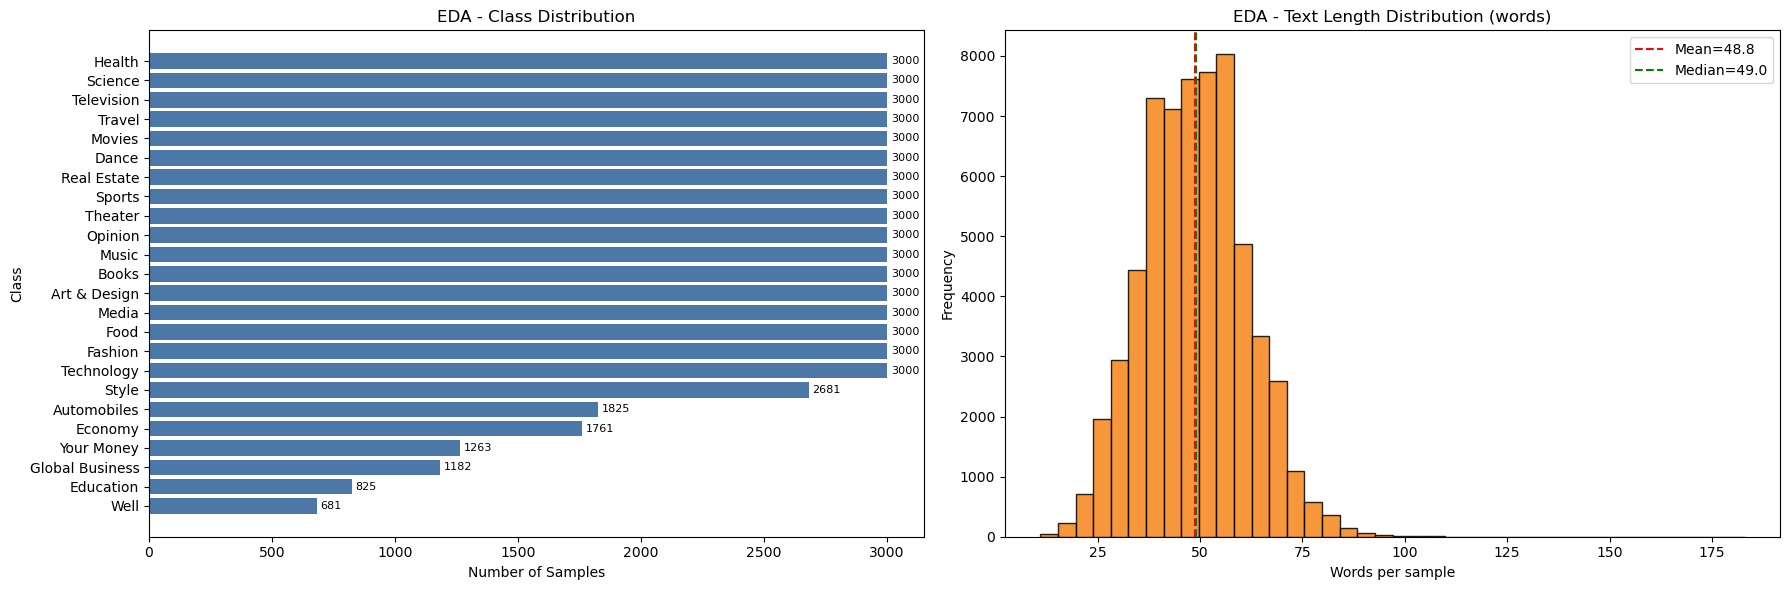

In [11]:
# EDA Visualization
try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError("matplotlib is required for EDA plots. Install it with: pip install matplotlib") from e

labels_series = [item["label"] for item in dataset.items]
text_lengths = [len(item["text"].split()) for item in dataset.items]
class_counts = Counter(labels_series)
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

class_names = [x[0] for x in sorted_counts]
sample_counts = [x[1] for x in sorted_counts]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Class distribution
axes[0].barh(class_names[::-1], sample_counts[::-1], color="#4C78A8")
axes[0].set_title("EDA - Class Distribution")
axes[0].set_xlabel("Number of Samples")
axes[0].set_ylabel("Class")
x_offset = max(sample_counts) * 0.005 if sample_counts else 0.0
for i, val in enumerate(sample_counts[::-1]):
    axes[0].text(val + x_offset, i, str(val), va="center", fontsize=8)

# Plot 2: Text length distribution
axes[1].hist(text_lengths, bins=40, color="#F58518", edgecolor="black", alpha=0.85)
mean_len = float(np.mean(text_lengths)) if text_lengths else 0.0
median_len = float(np.median(text_lengths)) if text_lengths else 0.0
axes[1].axvline(mean_len, color="red", linestyle="--", linewidth=1.5, label=f"Mean={mean_len:.1f}")
axes[1].axvline(median_len, color="green", linestyle="--", linewidth=1.5, label=f"Median={median_len:.1f}")
axes[1].set_title("EDA - Text Length Distribution (words)")
axes[1].set_xlabel("Words per sample")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Inference and Evaluation
records = pipeline.run_inference(loader, multimodal_alpha=0.7, show_progress=True)

# 5) Evaluate
image_metrics = evaluator.evaluate_from_records(records, pred_key="image_pred")
text_metrics = evaluator.evaluate_from_records(records, pred_key="text_pred")
multimodal_metrics = evaluator.evaluate_from_records(records, pred_key="multimodal_pred")

evaluator.print_metrics("Image-only Zero-shot (CLIP)", image_metrics)
evaluator.print_metrics("Text-only Zero-shot (CLIP)", text_metrics)
evaluator.print_metrics("Multimodal Zero-shot (Image + Text)", multimodal_metrics)

if cfg.cls_report:
    print("\nPer-class metrics sample (multimodal):")
    for row in multimodal_metrics["per_class"][:10]:
        print(row)

Zero-shot Inference:   0%|          | 0/1914 [00:00<?, ?it/s]


=== Image-only Zero-shot (CLIP) ===
Accuracy:         0.4223
Precision:        0.4163
Recall:           0.4223
F1-score:         0.4056
Macro Accuracy:   0.3973
Macro Precision:  0.3822
Macro Recall:     0.3973
Macro F1-score:   0.3764

=== Text-only Zero-shot (CLIP) ===
Accuracy:         0.4635
Precision:        0.5436
Recall:           0.4635
F1-score:         0.4302
Macro Accuracy:   0.4494
Macro Precision:  0.5081
Macro Recall:     0.4494
Macro F1-score:   0.4081

=== Multimodal Zero-shot (Image + Text) ===
Accuracy:         0.4991
Precision:        0.4889
Recall:           0.4991
F1-score:         0.4699
Macro Accuracy:   0.4728
Macro Precision:  0.4505
Macro Recall:     0.4728
Macro F1-score:   0.4385

Per-class metrics sample (multimodal):
{'label': 'Health', 'precision': 0.48910027744748313, 'recall': 0.41133333333333333, 'f1': 0.4468585913452834, 'support': 3000}
{'label': 'Books', 'precision': 0.5229838709677419, 'recall': 0.43233333333333335, 'f1': 0.47335766423357667, 'sup

In [10]:
# 6) Analysis
param_info = analyzer.model_params_info(pipeline.model)
print("=== Model Size Analysis ===")
print(f"Total parameters:     {param_info['total_params']:,}")
print(f"Trainable parameters: {param_info['trainable_params']:,}")
print(f"Estimated size (MB):  {param_info['model_size_mb']:.2f}")

timing = analyzer.benchmark_inference_time(loader, multimodal_alpha=0.7, warmup_steps=2, timed_steps=10)
print("\n=== Inference Time Analysis ===")
print(f"Timed steps:         {timing['timed_steps']}")
print(f"Total samples:       {timing['total_samples']}")
print(f"Total seconds:       {timing['total_seconds']:.4f}")
print(f"Seconds per sample:  {timing['seconds_per_sample']:.6f}")
print(f"Samples per second:  {timing['samples_per_second']:.2f}")

image_conf_table = analyzer.confidence_analysis(records, pred_key="image_pred", conf_key="image_confidence")
multimodal_conf_table = analyzer.confidence_analysis(records, pred_key="multimodal_pred", conf_key="multimodal_confidence")

analyzer.print_confidence_table("Image-only", image_conf_table)
analyzer.print_confidence_table("Multimodal", multimodal_conf_table)

=== Model Size Analysis ===
Total parameters:     151,277,313
Trainable parameters: 151,277,313
Estimated size (MB):  577.08

=== Inference Time Analysis ===
Timed steps:         10
Total samples:       320
Total seconds:       11.9279
Seconds per sample:  0.037275
Samples per second:  26.83

=== Image-only Confidence Analysis ===
Bin        | Count | Accuracy | Avg Confidence
-----------------------------------------------
[0.0, 0.2] | 61218 | 0.4223   | 0.0432
[0.2, 0.4] |     0 | 0.0000   | 0.0000
[0.4, 0.6] |     0 | 0.0000   | 0.0000
[0.6, 0.8] |     0 | 0.0000   | 0.0000
[0.8, 1.0] |     0 | 0.0000   | 0.0000

=== Multimodal Confidence Analysis ===
Bin        | Count | Accuracy | Avg Confidence
-----------------------------------------------
[0.0, 0.2] | 61218 | 0.4991   | 0.0431
[0.2, 0.4] |     0 | 0.0000   | 0.0000
[0.4, 0.6] |     0 | 0.0000   | 0.0000
[0.6, 0.8] |     0 | 0.0000   | 0.0000
[0.8, 1.0] |     0 | 0.0000   | 0.0000
